# Trabalho 3 - MC920 - Processamento de imagem digital

## Nícolas Hecker Silva (186132)

# Problema

(...)

alinhamento automático de imagens de documentos

(...)

In [1]:
# carregar e mostrar imagem neg_4.png
import cv2
import numpy as np
import matplotlib.pyplot as plt

def mostrar(imagens: list, titulos=[], cmaps=[], eixos = False, minmax=None, num=[]):
    if type(imagens) == list:
        if type(imagens[0]) == list:
            fig, axs = plt.subplots(len(imagens), len(imagens[0]), figsize=(5*len(imagens[0]), 5*len(imagens)))
            for i in range(len(imagens)):
                for j in range(len(imagens[i])):
                    imagem = imagens[i][j]
                    if cmaps[i]:
                        axs[i][j].imshow(imagem, cmap=cmaps[i][j])
                    else:
                        axs[i][j].imshow(imagem)
                    if titulos[i]:
                        axs[i][j].set_title(titulos[i][j])
                    if not eixos:
                        axs[i][j].axis("off")
                    if len(num) > 0 and num[i]:
                        for x in range(imagem.shape[0]):
                            for y in range(imagem.shape[1]):
                                axs[i][j].text(y, x, str(round(imagem[x,y],2)), ha='center', va='center', color='r', fontsize=8)
        else:
            fig, axs = plt.subplots(1, len(imagens), figsize=(5*len(imagens),5*len(imagens)))
            if len(imagens) == 1:
                axs = [axs]
            for i, imagem in enumerate(imagens):
                if cmaps:
                    axs[i].imshow(imagem, cmap=cmaps[i])
                else:
                    axs[i].imshow(imagem)
                if titulos:
                    axs[i].set_title(titulos[i])
                if not eixos:
                    axs[i].axis("off")
                if len(num) > 0 and num[i]:
                    for x in range(imagem.shape[0]):
                        for y in range(imagem.shape[1]):
                            axs[i].text(y, x, str(round(imagem[x,y],2)), ha='center', va='center', color='r', fontsize=8)
        #diminui distancia lateral
        plt.subplots_adjust(wspace=0.1, hspace=0.1)
    else:
        if type(cmaps) != list:
            plt.imshow(imagens, cmap=cmaps)
        else:
            plt.imshow(imagens)
        if type(titulos) != list:
            plt.title(titulos)
        if not eixos:
            plt.axis("off")
        if type(num) != list:
            for x in range(imagens.shape[0]):
                for y in range(imagens.shape[1]):
                    plt.text(y, x, str(round(imagem[x,y],2)), ha='center', va='center', color='r', fontsize=8)
    plt.show()
    

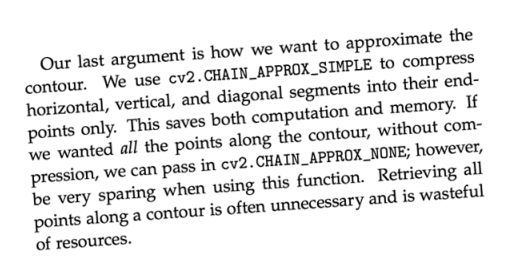

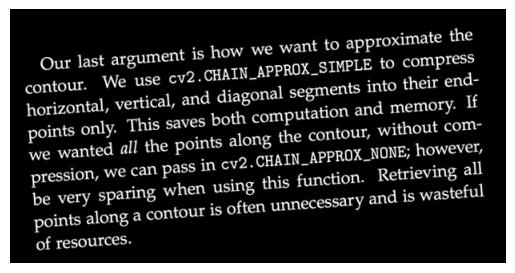

In [2]:

img = cv2.imread('neg_4.png', cv2.CHAIN_APPROX_SIMPLE)
mostrar(img, cmaps='gray')
imagem_neg = cv2.bitwise_not(img)
mostrar(imagem_neg, cmaps='gray')


## Alinhamento por projecao horizontal


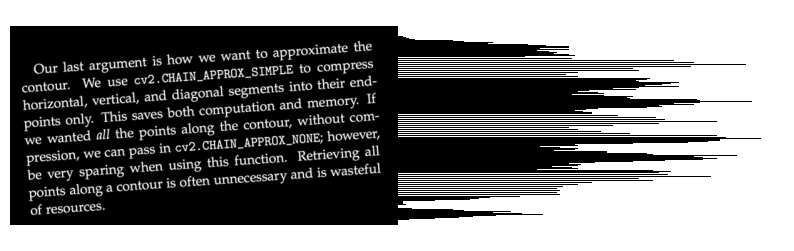

In [3]:
def rotaciona(imagem, angulo):
    return imagem.copy()

def encontrar_angulo_projecao_horizontal(imagem):
    angulo = 0
    angulo_teste = 0
    imagem_rotacionada = rotaciona(imagem, angulo_teste)
    linhas = []
    for linha in range(imagem_rotacionada.shape[0]):
        linhas.append(np.sum(imagem_rotacionada[linha] > 128))

    _, axs = plt.subplots(1, 2, figsize=(10,3))
    axs[0].imshow(imagem_rotacionada, cmap='gray')
    axs[0].axis("off")
    axs[1].barh(range(imagem_rotacionada.shape[0]), width=linhas[::], color='black')
    axs[1].invert_yaxis()
    axs[1].axis("off")
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

encontrar_angulo_projecao_horizontal(imagem_neg)

    

In [4]:
def rotaciona(imagem, angulo):
    centro = (imagem.shape[1]//2, imagem.shape[0]//2)
    matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    imagem_rotacionada = cv2.warpAffine(imagem, matriz_rotacao, (imagem.shape[1], imagem.shape[0]))
    return imagem_rotacionada

def encontrar_angulo_projecao_horizontal(imagem):
    angulo = (None, np.Inf)
    for angulo_teste in range(-180, 180):
        imagem_rotacionada = rotaciona(imagem, angulo_teste)
        linhas = []
        for linha in range(imagem_rotacionada.shape[0]):
            linhas.append(np.sum(imagem_rotacionada[linha] > 128))
        # conta a quantidade de linhas com pelo menos um pixel branco
        qtd_linhas_brancas = np.sum(np.array(linhas) > 0)
        if qtd_linhas_brancas < angulo[1]:
            angulo = (angulo_teste, qtd_linhas_brancas)
            print(angulo)
    return angulo[0]
    

print(encontrar_angulo_projecao_horizontal(imagem_neg))

(-180, 273)
(-10, 266)
(-9, 257)
(-8, 248)
(-7, 244)
(-6, 242)
(-5, 236)
(-4, 193)
-4


In [5]:
def encontrar_angulo_projecao_horizontal(imagem):
    angulo = (None, np.Inf)
    for angulo_teste in range(-180, 180):
        imagem_rotacionada = rotaciona(imagem, angulo_teste)
        linhas = []
        for linha in range(imagem_rotacionada.shape[0]):
            linhas.append(np.sum(imagem_rotacionada[linha] > 128))
        # conta a quantidade de linhas com pelo menos um pixel branco
        qtd_linhas_brancas = np.sum(np.array(linhas) > 0)
        if qtd_linhas_brancas < angulo[1]:
            angulo = (angulo_teste, qtd_linhas_brancas)
    return angulo[0]

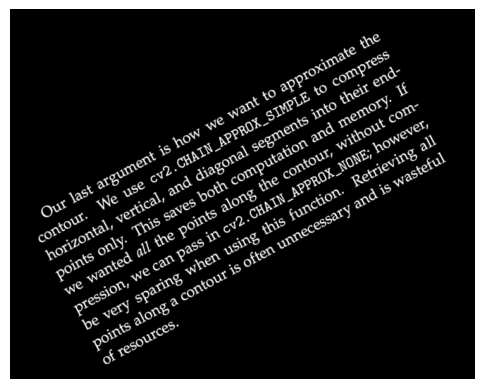

-28


In [6]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('neg_28.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))

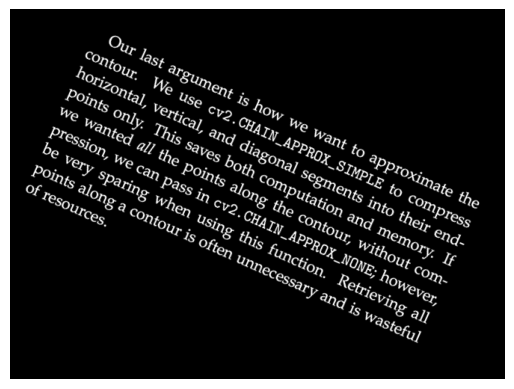

-156


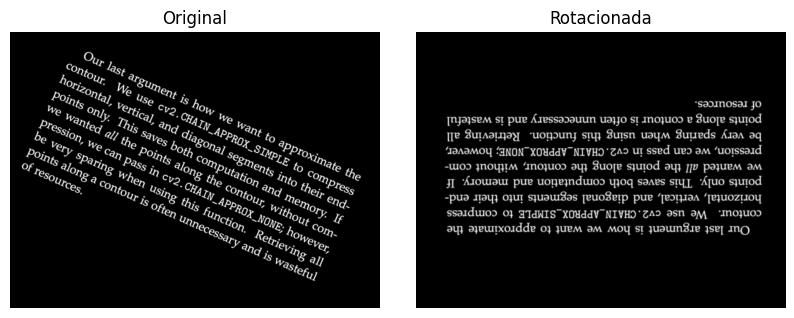

In [7]:
imagem_24 = cv2.bitwise_not(cv2.imread('pos_24.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_24, cmaps='gray')

angulo = encontrar_angulo_projecao_horizontal(imagem_24)
print(angulo)
imagem_rotacionada = rotaciona(imagem_24, angulo)
mostrar([imagem_24, imagem_rotacionada], ['Original', 'Rotacionada'], ['gray', 'gray'])

Nem todos os casos sao possiveis de resolver, exigindo analise manual, mas podemos pegar o menor angulo, pra isso fazemos modificacao no algoritmo:

In [8]:
def rotaciona(imagem, angulo):
    centro = (imagem.shape[1]//2, imagem.shape[0]//2)
    matriz_rotacao = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    imagem_rotacionada = cv2.warpAffine(imagem, matriz_rotacao, (imagem.shape[1], imagem.shape[0]))
    return imagem_rotacionada

def encontrar_angulo_projecao_horizontal(imagem):
    angulo = (None, np.Inf)
    for angulo_teste in range(0, 180):
        for i in range(-1, 2, 2):
            imagem_rotacionada = rotaciona(imagem, angulo_teste*i)
            linhas = []
            for linha in range(imagem_rotacionada.shape[0]):
                linhas.append(np.sum(imagem_rotacionada[linha] > 128))
            # conta a quantidade de linhas com pelo menos um pixel branco
            qtd_linhas_brancas = np.sum(np.array(linhas) > 0)
            if qtd_linhas_brancas < angulo[1]:
                angulo = (angulo_teste*i, qtd_linhas_brancas)
    return angulo[0]
    

print(encontrar_angulo_projecao_horizontal(imagem_24))

24


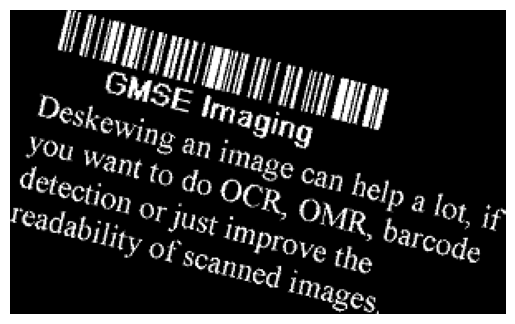

14


In [10]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('sample1.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))

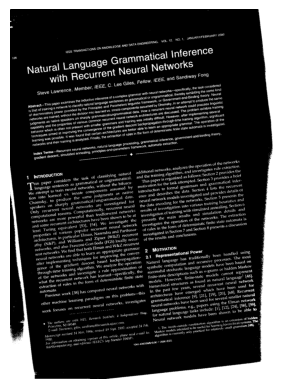

89


In [11]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('sample2.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))

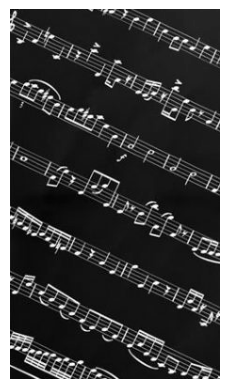

28


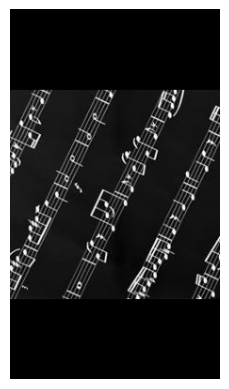

In [14]:
imagem_neg_28 = cv2.bitwise_not(cv2.imread('partitura.png', cv2.CHAIN_APPROX_SIMPLE))
mostrar(imagem_neg_28, cmaps='gray')

print(encontrar_angulo_projecao_horizontal(imagem_neg_28))
mostrar(rotaciona(imagem_neg_28, 90), cmaps='gray')